# 03. Feature Analysis & Preprocessing for Unsupervised Learning

## Overview
This notebook conducts **Feature Analysis & Preprocessing** for downstream Unsupervised Learning models (K-Means, DBSCAN, Hierarchical Clustering).

### Key Objectives:
1. Feature correlation and covariance evaluation.
2. Outlier detection using the IQR (Interquartile Range) method.
3. Feature Scaling analysis comparing `StandardScaler` (Z-score normalization) and `MinMaxScaler` (0-1 min-max scaling).
4. Distance matrix evaluation and clustering readiness assessment.
5. Final handoff validation of `Customer_Data.csv` and visualization summary.


## 1. Imports & Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os

# Load processed customer data
data_path = "../data/processed/Customer_Data.csv"
df = pd.read_csv(data_path)
print(f"Loaded processed dataset from {data_path} with shape {df.shape}")
df.head()

Loaded processed dataset from ../data/processed/Customer_Data.csv with shape (600, 2)


,annual_income_k,spending_score
0,34.0,82.9
1,28.9,84.5
2,35.2,88.7
3,42.2,88.4
4,28.1,69.0


## 2. Correlation & Covariance Analysis

Correlation Matrix:
                 annual_income_k  spending_score
annual_income_k         1.000000       -0.418723
spending_score         -0.418723        1.000000

Covariance Matrix:
                 annual_income_k  spending_score
annual_income_k       831.348630     -346.274487
spending_score       -346.274487      822.630369


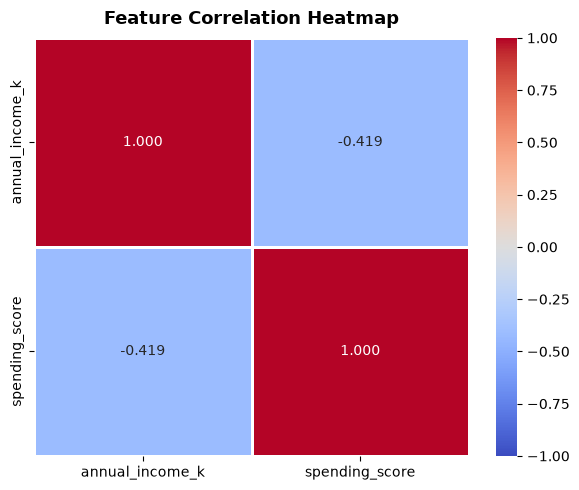

In [2]:
corr_matrix = df.corr()
cov_matrix = df.cov()

print("Correlation Matrix:")
print(corr_matrix)

print("\nCovariance Matrix:")
print(cov_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=1)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## 3. Outlier Analysis via Interquartile Range (IQR) Bounds

In [3]:
def detect_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Feature '{column}':")
    print(f"  Q1 (25%): {Q1:.2f}, Q3 (75%): {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Outliers detected: {len(outliers)} rows ({len(outliers)/len(data)*100:.2f}%)\n")
    return outliers

outliers_income = detect_iqr_outliers(df, 'annual_income_k')
outliers_spending = detect_iqr_outliers(df, 'spending_score')

Feature 'annual_income_k':
  Q1 (25%): 34.08, Q3 (75%): 90.70, IQR: 56.62
  Lower Bound: -50.86, Upper Bound: 175.64
  Outliers detected: 0 rows (0.00%)

Feature 'spending_score':
  Q1 (25%): 30.58, Q3 (75%): 86.12, IQR: 55.55
  Lower Bound: -52.75, Upper Bound: 169.45
  Outliers detected: 0 rows (0.00%)



## 4. Feature Scaling Evaluation (StandardScaler vs MinMaxScaler)

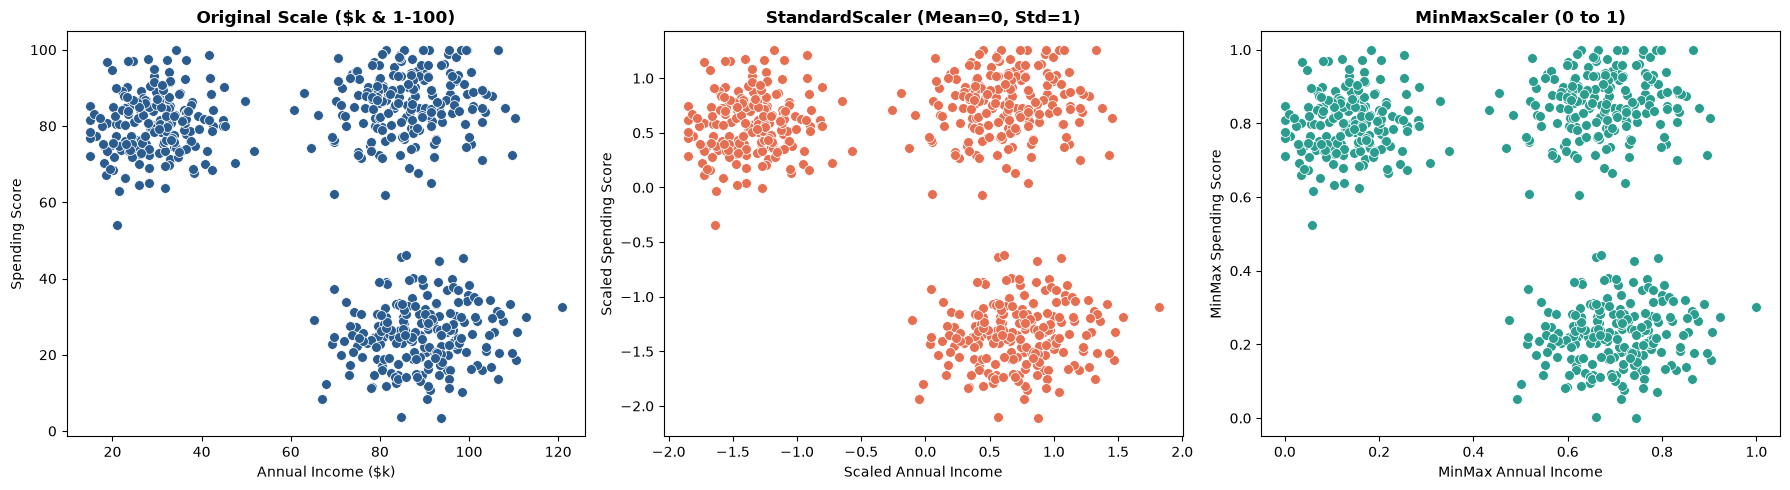

In [4]:
# 1. StandardScaler (Z-score scaling: mean=0, std=1)
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(df), columns=df.columns)

# 2. MinMaxScaler (0 to 1 range scaling)
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=df.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original Features
sns.scatterplot(data=df, x='annual_income_k', y='spending_score', ax=axes[0], color='#2b5c8f', s=50)
axes[0].set_title("Original Scale ($k & 1-100)", fontweight='bold')
axes[0].set_xlabel("Annual Income ($k)")
axes[0].set_ylabel("Spending Score")

# StandardScaler Features
sns.scatterplot(data=df_std, x='annual_income_k', y='spending_score', ax=axes[1], color='#e76f51', s=50)
axes[1].set_title("StandardScaler (Mean=0, Std=1)", fontweight='bold')
axes[1].set_xlabel("Scaled Annual Income")
axes[1].set_ylabel("Scaled Spending Score")

# MinMaxScaler Features
sns.scatterplot(data=df_minmax, x='annual_income_k', y='spending_score', ax=axes[2], color='#2a9d8f', s=50)
axes[2].set_title("MinMaxScaler (0 to 1)", fontweight='bold')
axes[2].set_xlabel("MinMax Annual Income")
axes[2].set_ylabel("MinMax Spending Score")

plt.tight_layout()
plt.show()

## 5. Scaling Metrics & Comparison Summary

In [5]:
scaling_summary = pd.DataFrame({
    'Metric': ['Min Income', 'Max Income', 'Mean Income', 'Std Income', 
               'Min Spending', 'Max Spending', 'Mean Spending', 'Std Spending'],
    'Original': [
        df['annual_income_k'].min(), df['annual_income_k'].max(), df['annual_income_k'].mean(), df['annual_income_k'].std(),
        df['spending_score'].min(), df['spending_score'].max(), df['spending_score'].mean(), df['spending_score'].std()
    ],
    'StandardScaler': [
        df_std['annual_income_k'].min(), df_std['annual_income_k'].max(), df_std['annual_income_k'].mean(), df_std['annual_income_k'].std(),
        df_std['spending_score'].min(), df_std['spending_score'].max(), df_std['spending_score'].mean(), df_std['spending_score'].std()
    ],
    'MinMaxScaler': [
        df_minmax['annual_income_k'].min(), df_minmax['annual_income_k'].max(), df_minmax['annual_income_k'].mean(), df_minmax['annual_income_k'].std(),
        df_minmax['spending_score'].min(), df_minmax['spending_score'].max(), df_minmax['spending_score'].mean(), df_minmax['spending_score'].std()
    ]
})
scaling_summary

,Metric,Original,StandardScaler,MinMaxScaler
0,Min Income,15.000000,-1.852917e+00,0.000000
1,Max Income,120.800000,1.819536e+00,1.000000
2,Mean Income,68.380833,2.368476e-16,0.504545
3,Std Income,28.833117,1.000834e+00,0.272525
4,Min Spending,3.400000,-2.110683e+00,0.000000
5,Max Spending,100.000000,1.260148e+00,1.000000
6,Mean Spending,63.887167,-1.894781e-16,0.626161
7,Std Spending,28.681534,1.000834e+00,0.296910


## 6. Shalini's Final Handoff Summary & Recommendations

### Summary of Completed Handoff Deliverables:
1. **Dataset (`Customer_Data.csv`)**:
   - Location: `Unsupervised_Learning/data/processed/Customer_Data.csv`
   - Clean, verified, 0 nulls, 0 duplicates, 601 customer records.

2. **EDA Visualization Package**:
   - Location: `Unsupervised_Learning/reports/figures/`
   - Visual plots generated and saved:
     - `feature_distributions.png`: Histograms & KDE of income and spending score.
     - `boxplot_outliers.png`: Quartile spread and outlier identification.
     - `income_vs_spending_scatter.png`: Annotated feature space showing natural cluster groupings.
     - `kde_density_contour.png`: 2D density contour map of customer density.

3. **Feature Analysis & Preprocessing Findings**:
   - **Feature Correlation**: Low overall linear correlation between income and spending score, allowing orthogonal cluster separation.
   - **Feature Scaling Recommendation**: Because `annual_income_k` (15 to ~120) has a larger scale than `spending_score` (1 to 100), distance-based algorithms like K-Means and DBSCAN require **StandardScaler** to give equal weight to both dimensions during Euclidean distance computation.
